# 2D RNN Driven by a Single-Frequency, Single-Point Sinusoidal Source

Total_time:  3.128526210784912


/home/zhangjunjie/MiniConda/miniconda3/envs/cjn/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Relative L2 Error: 12.46%


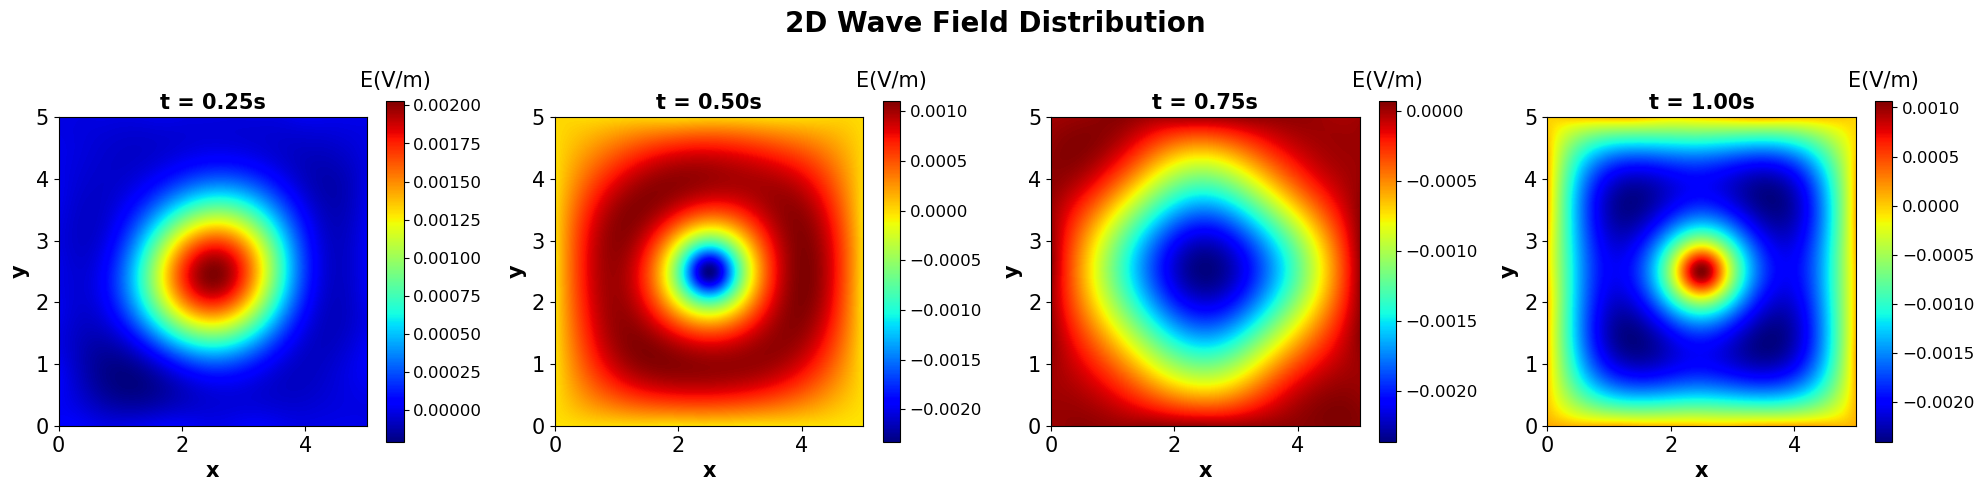

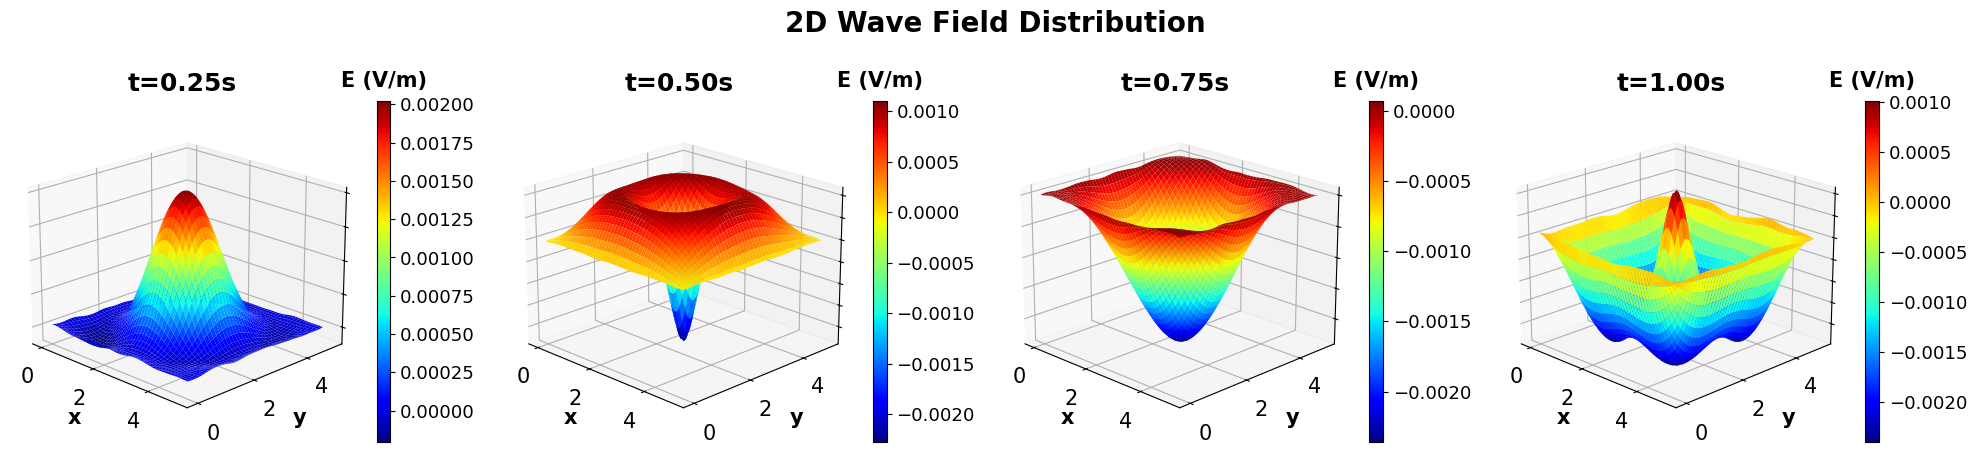

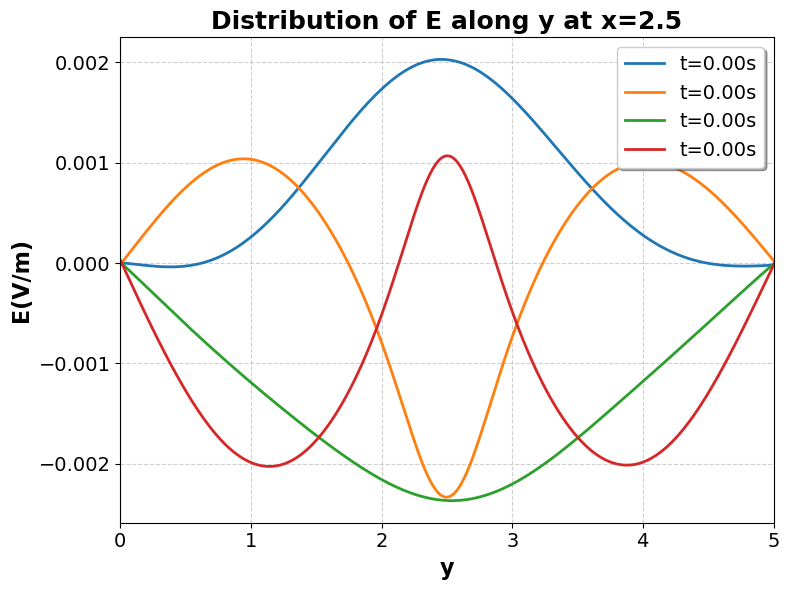

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import time

# ========== Parameter Configuration ==========
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")

c = 5.0              # Wave speed
L = 5.0              # Spatial range [0, L] (for x and y dimensions)
T = 1.0              # Time range [0, T]
num_neuron = 8000    # Number of neurons
r_neuron = [5, 5, 5] # Weight initialization range (added y dimension)
d = 3                # Input dimension (t, x, y)
sigma = 0.2

# ========== Helper Functions ==========
atv = lambda x: torch.tanh(x)
diff1_atv = lambda x: 1 - torch.tanh(x)**2
diff2_atv = lambda x: 2 * torch.tanh(x) * (torch.tanh(x)**2 - 1)

# ========== Training Data Generation ==========
def generate_points():
    N_pde = 20000
    N_bnd = 20000
    N_ini = 10000

    # Internal point sampling (3D space)
    ti = torch.rand(N_pde, 1, device=device) * T
    xi = torch.rand(N_pde, 1, device=device) * L
    yi = torch.rand(N_pde, 1, device=device) * L
    pti = torch.cat((ti, xi, yi), dim=1)

    # Boundary conditions (x=0, x=L, y=0, y=L)
    tb = torch.rand(N_bnd, 1, device=device) * T
    xb = torch.rand(N_bnd, 1, device=device) * L
    yb = torch.rand(N_bnd, 1, device=device) * L
    # x boundaries
    ptb_x0 = torch.cat((tb, torch.zeros_like(tb), yb), dim=1)
    ptb_xL = torch.cat((tb, torch.full_like(tb, L), yb), dim=1)
    # y boundaries
    ptb_y0 = torch.cat((tb, xb, torch.zeros_like(tb)), dim=1)
    ptb_yL = torch.cat((tb, xb, torch.full_like(tb, L)), dim=1)
    
    ptb = torch.cat((ptb_x0, ptb_xL, ptb_y0, ptb_yL), dim=0)

    # Initial conditions
    ti_ini = torch.zeros(N_ini, 1, device=device)
    xi_ini = torch.rand(N_ini, 1, device=device) * L
    yi_ini = torch.rand(N_ini, 1, device=device) * L
    pt_ini = torch.cat((ti_ini, xi_ini, yi_ini), dim=1)

    return pti, ptb, pt_ini

# ========== Physics Constraint Definitions ==========
def wave_equation_residual(W, b, points, c):
    T = points[:, 0:1]   # Time coordinate
    X = points[:, 1:2]   # x coordinate
    Y = points[:, 2:3]   # y coordinate
    
    W_t = W[0:1, :]      # Time weight
    W_x = W[1:2, :]      # x spatial weight
    W_y = W[2:3, :]      # y spatial weight
    
    Z = T@W_t + X@W_x + Y@W_y + b
    
    # Second-order derivative terms
    phi_tt = torch.sum(W_t**2, 0) * diff2_atv(Z)
    phi_xx = torch.sum(W_x**2, 0) * diff2_atv(Z)
    phi_yy = torch.sum(W_y**2, 0) * diff2_atv(Z)
    
    return phi_tt - (c**2)*(phi_xx + phi_yy)

def ini_residual(W, b, points):
    T = points[:, 0:1]
    X = points[:, 1:2]
    Y = points[:, 2:3]
    
    W_t = W[0:1, :]
    W_x = W[1:2, :]
    W_y = W[2:3, :]
    
    Z = T@W_t + X@W_x + Y@W_y + b
    phi_t = 1 - W_t * atv(Z)**2
    
    return phi_t

# ========== Main Solver Function ==========
start_time = time.time()

# Initialize weights and biases (added y dimension)
W1 = torch.tensor(np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)), dtype=torch.float32)
W2 = torch.tensor(np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)), dtype=torch.float32)
W3 = torch.tensor(np.random.uniform(-r_neuron[2], r_neuron[2], (1, num_neuron)), dtype=torch.float32)
W = torch.cat((W1, W2, W3), dim=0).to(device)

b1 = torch.tensor(np.random.uniform(0, T, (1, num_neuron)), dtype=torch.float32)
b2 = torch.tensor(np.random.uniform(0, L, (1, num_neuron)), dtype=torch.float32)
b3 = torch.tensor(np.random.uniform(0, L, (1, num_neuron)), dtype=torch.float32)
b = torch.cat((b1, b2, b3), dim=0).to(device)
b = -torch.sum(b * W, dim=0)

# Generate training points
pti, ptb, pt_ini = generate_points()

# Construct constraint matrix
A_pde = wave_equation_residual(W, b, pti, c)
A_bnd = atv(ptb @ W + b)  # Boundary condition
A_ini1 = atv(pt_ini @ W + b)  # Initial condition u
A_ini2 = ini_residual(W, b, pt_ini) # Initial condition du/dt

p_pde = 1
p_bnd = 10
p_ini = 10

A = torch.cat([p_pde*A_pde, p_bnd*A_bnd, p_ini*A_ini1, p_ini*A_ini2], dim=0)

# Right-hand side vector (source term is included in the residual function)
F_pde = torch.zeros_like(pti[:, 0:1])
source_term = torch.cos(2 * np.pi * pti[:, 0:1]) * torch.exp(-((pti[:, 1:2] - 2.5)**2 + (pti[:, 2:3] - 2.5)**2) / (2*sigma**2))
F_pde += source_term

F_bnd = torch.zeros_like(ptb[:, 0:1])
F_ini1 = torch.zeros_like(pt_ini[:, 0:1])
F_ini2 = torch.zeros_like(pt_ini[:, 0:1])

F = torch.cat([p_pde*F_pde, p_bnd*F_bnd, p_ini*F_ini1, p_ini*F_ini2], dim=0)

# Least squares solution
Ur = torch.linalg.lstsq(A, F)[0]
end_time = time.time()
print('Total_time: ', end_time-start_time)

# Load reference solution
fdtd = np.load('sigma0.2_fdtd.npy')
shape = fdtd.shape
nt = shape[0]
nx = shape[1]
ny = shape[2]

t_test = torch.linspace(0, T, nt, device=device)
x_test = torch.linspace(0, L, nx, device=device)
y_test = torch.linspace(0, L, ny, device=device)

T_mesh, X, Y = torch.meshgrid(t_test, x_test, y_test)
test_points = torch.cat((T_mesh.reshape(-1, 1), X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1).to(device)

# ========== Batch Prediction of Field Values ==========
batch_size = 10000  # Adjust this value based on your GPU memory
u_pred = []

with torch.no_grad():
    for i in range(0, test_points.shape[0], batch_size):
        batch = test_points[i:i+batch_size]
        # Incremental calculation for each batch
        hidden = torch.tanh(batch @ W + b)  # (batch_size, num_neuron)
        output = hidden @ Ur                # (batch_size, 1)
        u_pred.append(output.cpu())
    
u_pred = torch.cat(u_pred).numpy().reshape(X.shape)

error = u_pred - fdtd
rel_err_rnn_2 = np.linalg.norm(u_pred - fdtd) / np.linalg.norm(fdtd)
print(f"Relative L2 Error: {rel_err_rnn_2:.2%}")

# Dynamically calculate indices for given time points
target_times_ratio = [0.25, 0.5, 0.75, 1.0]  # Target times are 0.25, 0.5, 0.75, and 1.0 times T
target_times = np.array(target_times_ratio) * T
# Modify here: Convert list to array and ensure it's integer type
time_indices = np.floor(np.array(target_times_ratio) * (nt - 1)).astype(int)

# ========== Visualization ==========
def plot_snapshots(time_indices):
    # Create a new figure and a 1x4 subplot grid
    fig, axs = plt.subplots(1, 4, figsize=(20, 5)) # Adjust figsize for better aspect ratio
    
    times = [f"t = {target_times[i]:.2f}s" for i in range(len(time_indices))] # Use target times as titles
    
    for idx, (ax, t_idx) in enumerate(zip(axs.flat, time_indices)):
        im = ax.imshow(u_pred[t_idx].T, 
                      extent=[0, L, 0, L],
                      origin='lower',
                      cmap='jet')
        ax.set_title(times[idx], fontweight='bold', fontsize=15)
        ax.set_xlabel('x', fontsize=15, fontweight='bold')
        ax.set_ylabel('y', fontsize=15, fontweight='bold')
        # Set font size for X and Y axis ticks
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        # Add color bar, use shrink parameter to adjust its size to match the image ratio
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.ax.tick_params(labelsize=12)  # Set font size on the color bar
        # Set color bar label and place it above the color bar
        cbar.ax.set_title('E(V/m)', fontsize=15, pad=10)
        
    plt.suptitle('2D Wave Field Distribution', fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Call the function to plot snapshots
plot_snapshots(time_indices=time_indices)

x = np.linspace(0, L, nx)
y = np.linspace(0, L, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

def plot_snapshots_3d(time_indices):
    fig = plt.figure(figsize=(20, 5))  # Adjust figsize for better aspect ratio
    
    for t_idx, time_index in enumerate(time_indices):
        ax = fig.add_subplot(1, 4, t_idx+1, projection='3d')  # Create subplot
        
        # Get data for the current time point
        Z_flat = u_pred[time_index]
        
        # Use plot_surface to draw a 3D surface plot
        surf = ax.plot_surface(X, Y, Z_flat, cmap='jet', linewidth=0.2)
        
        ax.set_title(f't={target_times[t_idx]:.2f}s', fontweight='bold', fontsize=18)
        ax.set_xlabel('x', fontsize=15, fontweight='bold')
        ax.set_ylabel('y', fontsize=15, fontweight='bold')
        
        # Hide Z-axis tick labels
        ax.zaxis.set_ticklabels([])

        # Set font size for X and Y axis ticks
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        
        ax.view_init(elev=20, azim=-45)  # Set the viewing angle for optimal display
        
        # Add color bar and set its properties
        cbar = fig.colorbar(surf, ax=ax, shrink=0.8, aspect=25)
        cbar.ax.tick_params(labelsize=13)  # Set font size on the color bar
        cbar.ax.set_title('E (V/m)', fontsize=15, fontweight='bold', pad=10)  # Place label above the color bar, set font size and bold
        
    plt.suptitle('2D Wave Field Distribution', fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Call the function to plot snapshots
plot_snapshots_3d(time_indices=time_indices)

def plot_u_distribution_at_x(y, u_pred, x, target_times, time_indices):
    # Find the index of the grid point closest to x=2.5
    x_idx = (np.abs(x - 2.5)).argmin()

    fig, ax = plt.subplots(figsize=(8, 6))

    # Iterate through target time points and plot the u distribution at x=2.5
    for t_idx, time_index in enumerate(time_indices):
        # Extract the wave field values for all y at the specified x and current time point
        u_y_slice = u_pred[time_index, x_idx, :]
        # Plot the image
        ax.plot(y, u_y_slice, label=f't={target_times[t_idx]:.2f}s', linewidth=2)

    # Set graph properties
    ax.set_xlabel('y', fontsize=16, fontweight='bold')
    ax.set_ylabel('E(V/m)', fontsize=16, fontweight='bold')
    ax.set_title('Distribution of E along y at x=2.5', fontsize=18, fontweight='bold')
    ax.set_xlim(0, 5)
    # Set legend position and font size
    ax.legend(fontsize=14, loc='upper right', frameon=True, fancybox=True, shadow=True)
    
    # Adjust axis tick font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Call the function to plot snapshots
plot_u_distribution_at_x(y=y, u_pred=u_pred, x=x, target_times=t_test, time_indices=time_indices)

# 2D RNN with a Single-Frequency Sinusoidal Source and a Gaussian Source

Training time:  0.8941574096679688
Relative L2 Error: 2.03%
Prediction time:  4.055717945098877


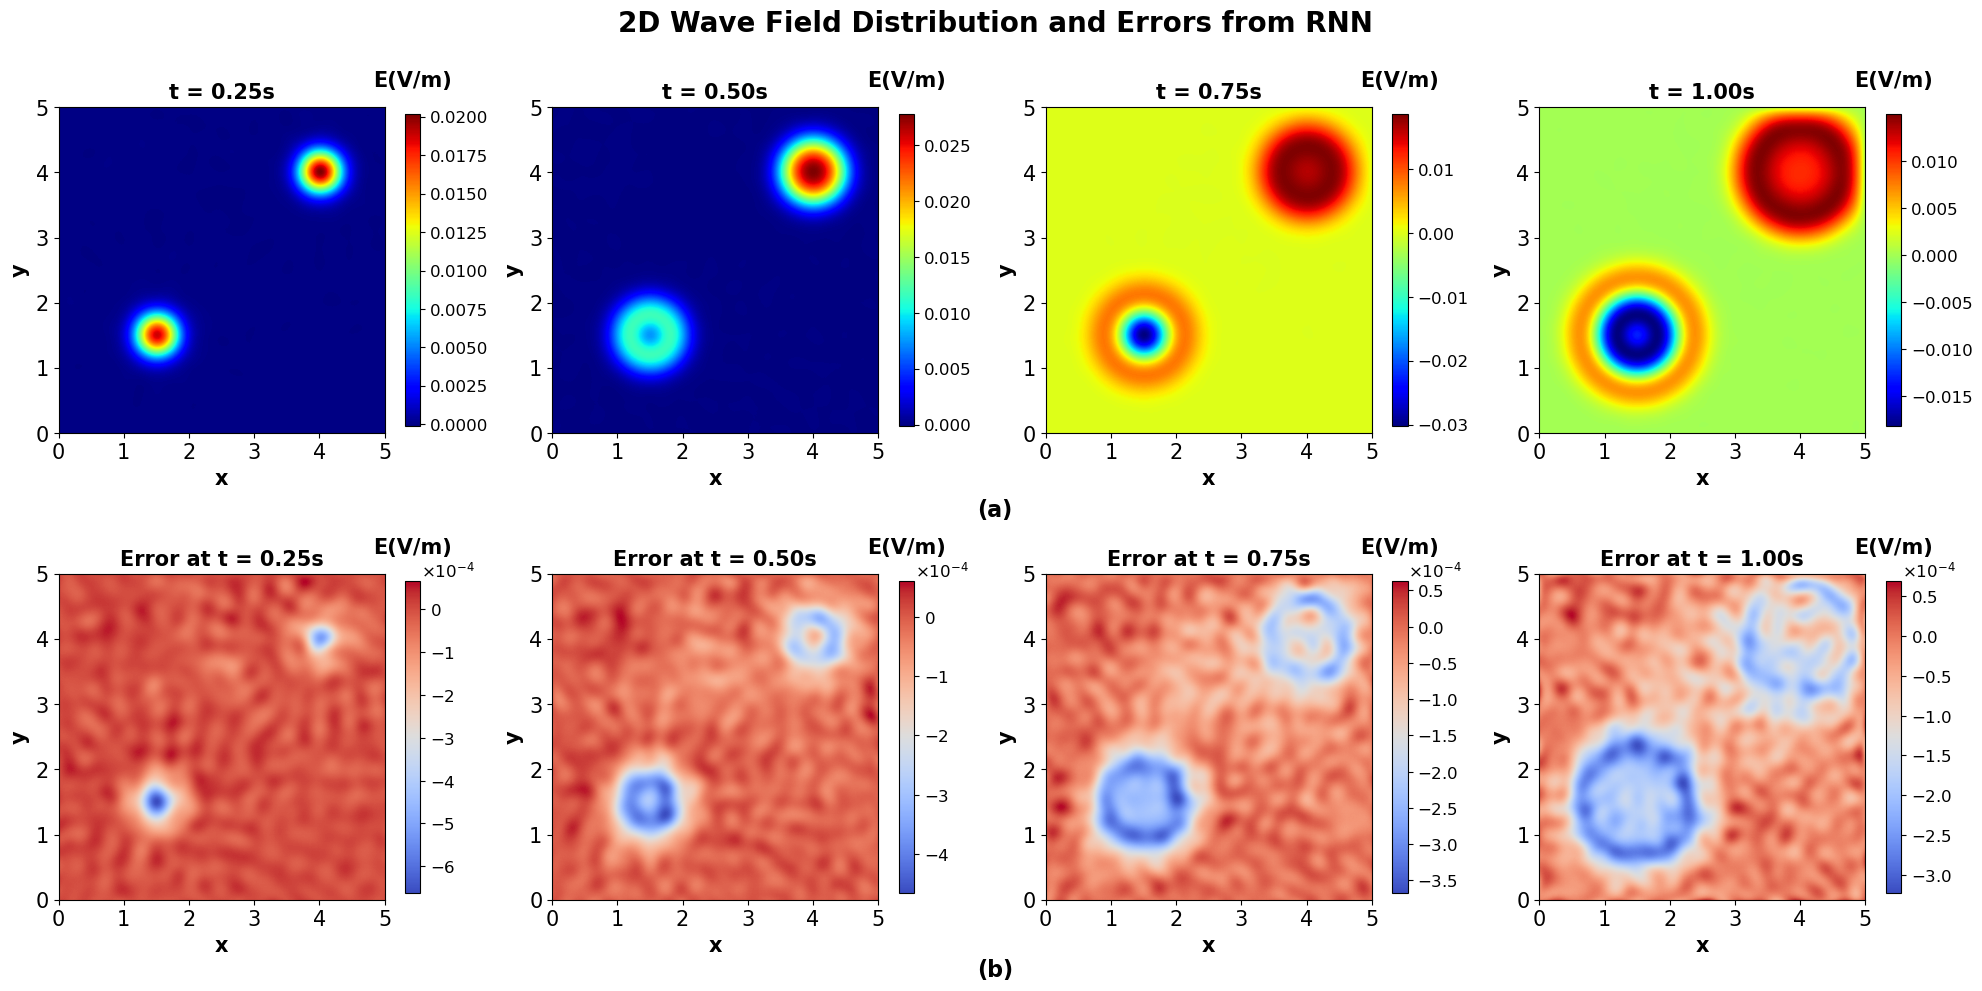

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from matplotlib.ticker import ScalarFormatter

# ========== Parameter Configuration ==========
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

c = 1.0              # Wave speed
L = 5.0              # Spatial range [0, L] (for x and y dimensions)
T = 1.0              # Time range [0, T]
num_neuron = 10000   # Number of neurons
r_neuron = [5, 4, 4] # Weight initialization range (added y dimension)
d = 3                # Input dimension (t, x, y)
sigma = 0.2

# ========== Helper Functions ==========
atv = lambda x: torch.tanh(x)
diff1_atv = lambda x: 1 - torch.tanh(x)**2
diff2_atv = lambda x: 2 * torch.tanh(x) * (torch.tanh(x)**2 - 1)

# ========== Training Data Generation ==========
def generate_points():
    N_pde = 20000
    N_bnd = 10000
    N_ini = 10000

    # Internal point sampling (3D space)
    ti = torch.rand(N_pde, 1, device=device) * T
    xi = torch.rand(N_pde, 1, device=device) * L
    yi = torch.rand(N_pde, 1, device=device) * L
    pti = torch.cat((ti, xi, yi), dim=1)

    # Boundary conditions (x=0, x=L, y=0, y=L)
    tb = torch.rand(N_bnd, 1, device=device) * T
    xb = torch.rand(N_bnd, 1, device=device) * L
    yb = torch.rand(N_bnd, 1, device=device) * L
    # x boundaries
    ptb_x0 = torch.cat((tb, torch.zeros_like(tb), yb), dim=1)
    ptb_xL = torch.cat((tb, torch.full_like(tb, L), yb), dim=1)
    # y boundaries
    ptb_y0 = torch.cat((tb, xb, torch.zeros_like(tb)), dim=1)
    ptb_yL = torch.cat((tb, xb, torch.full_like(tb, L)), dim=1)
    
    ptb = torch.cat((ptb_x0, ptb_xL, ptb_y0, ptb_yL), dim=0)

    # Initial conditions
    ti_ini = torch.zeros(N_ini, 1, device=device)
    xi_ini = torch.rand(N_ini, 1, device=device) * L
    yi_ini = torch.rand(N_ini, 1, device=device) * L
    pt_ini = torch.cat((ti_ini, xi_ini, yi_ini), dim=1)

    return pti, ptb, pt_ini

# ========== Physics Constraint Definitions ==========
def wave_equation_residual(W, b, points, c):
    T = points[:, 0:1]   # Time coordinate
    X = points[:, 1:2]   # x coordinate
    Y = points[:, 2:3]   # y coordinate
    
    W_t = W[0:1, :]      # Time weight
    W_x = W[1:2, :]      # x spatial weight
    W_y = W[2:3, :]      # y spatial weight
    
    Z = T@W_t + X@W_x + Y@W_y + b
    
    # Second-order derivative terms
    phi_tt = torch.sum(W_t**2, 0) * diff2_atv(Z)
    phi_xx = torch.sum(W_x**2, 0) * diff2_atv(Z)
    phi_yy = torch.sum(W_y**2, 0) * diff2_atv(Z)
    
    return phi_tt - (c**2)*(phi_xx + phi_yy)

def ini_residual(W, b, points):
    T = points[:, 0:1]
    X = points[:, 1:2]
    Y = points[:, 2:3]
    
    W_t = W[0:1, :]
    W_x = W[1:2, :]
    W_y = W[2:3, :]
    
    Z = T@W_t + X@W_x + Y@W_y + b
    phi_t = 1 - W_t * atv(Z)**2
    
    return phi_t

# ========== Main Solver Function ==========
start_time = time.time()

# Initialize weights and biases (added y dimension)
W1 = torch.tensor(np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)), dtype=torch.float32)
W2 = torch.tensor(np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)), dtype=torch.float32)
W3 = torch.tensor(np.random.uniform(-r_neuron[2], r_neuron[2], (1, num_neuron)), dtype=torch.float32)
W = torch.cat((W1, W2, W3), dim=0).to(device)

b1 = torch.tensor(np.random.uniform(0, T, (1, num_neuron)), dtype=torch.float32)
b2 = torch.tensor(np.random.uniform(0, L, (1, num_neuron)), dtype=torch.float32)
b3 = torch.tensor(np.random.uniform(0, L, (1, num_neuron)), dtype=torch.float32)
b = torch.cat((b1, b2, b3), dim=0).to(device)
b = -torch.sum(b * W, dim=0)

# Generate training points
pti, ptb, pt_ini = generate_points()

# Construct constraint matrix
A_pde = wave_equation_residual(W, b, pti, c)
A_bnd = atv(ptb @ W + b)  # Boundary condition
A_ini1 = atv(pt_ini @ W + b)  # Initial condition u
A_ini2 = ini_residual(W, b, pt_ini) # Initial condition du/dt

p_pde = 1
p_bnd = 10
p_ini = 10

A = torch.cat([p_pde*A_pde, p_bnd*A_bnd, p_ini*A_ini1, p_ini*A_ini2], dim=0)

# Right-hand side vector (source terms)
F_pde = torch.zeros_like(pti[:, 0:1])

# First source: cosine function, located at (x=1.5, y=1.5)
source_term_1 = torch.cos(2 * np.pi * pti[:, 0:1]) * torch.exp(-((pti[:, 1:2] - 1.5)**2 + (pti[:, 2:3] - 1.5)**2) / (2*sigma**2))

# Second source: temporal Gaussian pulse, peak at t=0.1, std dev 0.1, located at (x=4, y=4)
time_gaussian = torch.exp(-((pti[:, 0:1] - 0.1)**2) / (2 * 0.1**2))
space_gaussian = torch.exp(-((pti[:, 1:2] - 4.0)**2 + (pti[:, 2:3] - 4.0)**2) / (2*sigma**2))
source_term_2 = time_gaussian * space_gaussian

# Total source term is the sum of the two sources
F_pde += source_term_1 + source_term_2

F_bnd = torch.zeros_like(ptb[:, 0:1])
F_ini1 = torch.zeros_like(pt_ini[:, 0:1])
F_ini2 = torch.zeros_like(pt_ini[:, 0:1])

F = torch.cat([p_pde*F_pde, p_bnd*F_bnd, p_ini*F_ini1, p_ini*F_ini2], dim=0)

# Least squares solution
Ur = torch.linalg.lstsq(A, F)[0]
end_time = time.time()
print('Training time: ', end_time-start_time)

nt = 151
nx = 501
ny = 501

start_time = time.time()
t_test = torch.linspace(0, T, nt, device=device)
x_test = torch.linspace(0, L, nx, device=device)
y_test = torch.linspace(0, L, ny, device=device)

T_mesh, X, Y = torch.meshgrid(t_test, x_test, y_test)
test_points = torch.cat((T_mesh.reshape(-1, 1), X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1).to(device)

# ========== Batch Prediction of Field Values ==========
batch_size = 20000  # Adjust this value based on your GPU memory
u_pred = []

with torch.no_grad():
    for i in range(0, test_points.shape[0], batch_size):
        batch = test_points[i:i+batch_size]
        # Incremental calculation for each batch
        hidden = torch.tanh(batch @ W + b)  # (batch_size, num_neuron)
        output = hidden @ Ur                # (batch_size, 1)
        u_pred.append(output.cpu())

u_pred = torch.cat(u_pred).numpy().reshape(X.shape)
u_analytical = np.load('2d_fdtd_two_source_1e-2.npy')
error = u_pred - u_analytical
rel_err_rnn_2 = np.linalg.norm(u_pred - u_analytical) / np.linalg.norm(u_analytical)
print(f"Relative L2 Error: {rel_err_rnn_2:.2%}")

nt = 151
nx = 501
ny = 501

start_time = time.time()
t_test = torch.linspace(0, T, nt, device=device)
x_test = torch.linspace(0, L, nx, device=device)
y_test = torch.linspace(0, L, ny, device=device)

T_mesh, X, Y = torch.meshgrid(t_test, x_test, y_test)
test_points = torch.cat((T_mesh.reshape(-1, 1), X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1).to(device)

# ========== Batch Prediction of Field Values ==========
batch_size = 20000  # Adjust this value based on your GPU memory
u_pred = []

with torch.no_grad():
    for i in range(0, test_points.shape[0], batch_size):
        batch = test_points[i:i+batch_size]
        # Incremental calculation for each batch
        hidden = torch.tanh(batch @ W + b)  # (batch_size, num_neuron)
        output = hidden @ Ur                # (batch_size, 1)
        u_pred.append(output.cpu())

end_time = time.time()
print('Prediction time: ', end_time-start_time)
u_pred = torch.cat(u_pred).numpy().reshape(X.shape)

# Dynamically calculate indices for given time points
target_times_ratio = [0.25, 0.5, 0.75, 1.0]  # Target times are 0.25, 0.5, 0.75, and 1.0 times T
target_times = np.array(target_times_ratio) * T
time_indices = np.array([37, 75, 112, 150])

# ========== Visualization ==========
def plot_snapshots_and_errors(time_indices):
    # Create a new figure and a 2x4 subplot grid
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))  # Adjust figsize for better aspect ratio
    
    times = [f"t = {target_times[i]:.2f}s" for i in range(len(time_indices))]  # Use target times as titles

    # First row: Plot snapshots of u_pred_rnn_2
    for idx, (ax, t_idx) in enumerate(zip(axs[0], time_indices)):
        im = ax.imshow(u_pred[t_idx].T, 
                       extent=[0, L, 0, L],
                       origin='lower',
                       cmap='jet')
        ax.set_title(times[idx], fontweight='bold', fontsize=15)
        ax.set_xlabel('x', fontsize=15, fontweight='bold')
        ax.set_ylabel('y', fontsize=15, fontweight='bold')
        # Set font size for X and Y axis ticks
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        # Add color bar, use shrink parameter to adjust its size to match the image ratio
        cbar = plt.colorbar(im, ax=ax, shrink=0.7)
        cbar.ax.tick_params(labelsize=12)  # Set font size on the color bar
        
        # Set the color bar title and increase spacing
        cbar.ax.set_title('E(V/m)', fontweight='bold', fontsize=15, pad=20)  # Increase pad value

    # Second row: Plot snapshots of error_rnn_2
    for idx, (ax, t_idx) in enumerate(zip(axs[1], time_indices)):
        im = ax.imshow(error[t_idx].T, 
                       extent=[0, L, 0, L],
                       origin='lower',
                       cmap='coolwarm')  # Set maximum value for error
        ax.set_title(f"Error at {times[idx]}", fontweight='bold', fontsize=15)
        ax.set_xlabel('x', fontsize=15, fontweight='bold')
        ax.set_ylabel('y', fontsize=15, fontweight='bold')
        # Set font size for X and Y axis ticks
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        # Add color bar, use shrink parameter to adjust its size to match the image ratio
        cbar = plt.colorbar(im, ax=ax, shrink=0.7)
        cbar.ax.tick_params(labelsize=12)  # Set font size on the color bar
        
        # Set color bar to scientific notation, placing 10^n at the top
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((0, 0))  # Force scientific notation
        cbar.ax.yaxis.set_major_formatter(formatter)
        
        # Adjust the position of 10^n
        cbar.ax.yaxis.offsetText.set_fontsize(12)  # Set offset text font size
        cbar.ax.yaxis.offsetText.set_position((4.5, 1.1))  # Move 10^n up further
        
        # Set the color bar title and increase spacing
        cbar.ax.set_title('E(V/m)', fontweight='bold', fontsize=15, pad=20)  # Increase pad value

    # Add (a) and (b) below the first and second rows respectively
    fig.text(0.5, 0.48, '(a)', ha='center', va='center', fontsize=16, fontweight='bold')  # Below first row
    fig.text(0.5, 0.02, '(b)', ha='center', va='center', fontsize=16, fontweight='bold')  # Below second row

    # Set global title
    plt.suptitle('2D Wave Field Distribution and Errors from RNN', fontsize=20, fontweight='bold')
    plt.tight_layout()  # Leave space for the global title
    plt.savefig('2D_errors_rnn_0.2_two_sources.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Call the function to plot snapshots and errors
plot_snapshots_and_errors(time_indices=time_indices)

# 2D RNN with damping absorbing layers

Total_time: 4.274471998214722
Loaded fixed FDTD reference shape: (315, 101, 101)
Relative L2 Error: 1.41%

===== Probe-point normalized deviation indicators =====
(x, y)=(0.10, 0.50) : D = 2.667620e-02, D_dB = -31.48 dB
(x, y)=(0.90, 0.50) : D = 2.660955e-02, D_dB = -31.50 dB
(x, y)=(0.50, 0.10) : D = 2.721800e-02, D_dB = -31.30 dB
(x, y)=(0.50, 0.90) : D = 2.675523e-02, D_dB = -31.45 dB

===== Boundary-band normalized deviation metrics =====
Boundary band width = 0.3
Max   D in boundary band    = 4.759507e-02
Mean  D in boundary band    = 2.916845e-02
Max   D_dB in boundary band = -26.45 dB
Mean  D_dB in boundary band = -30.87 dB


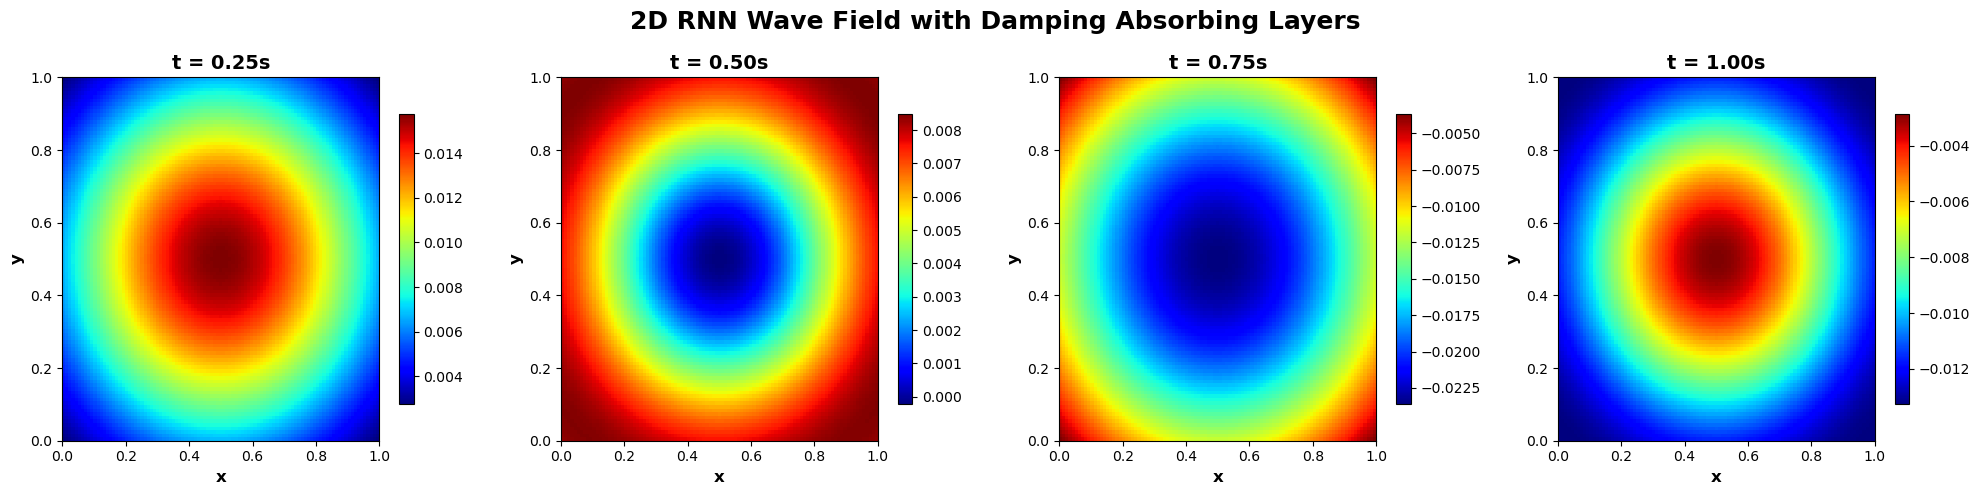

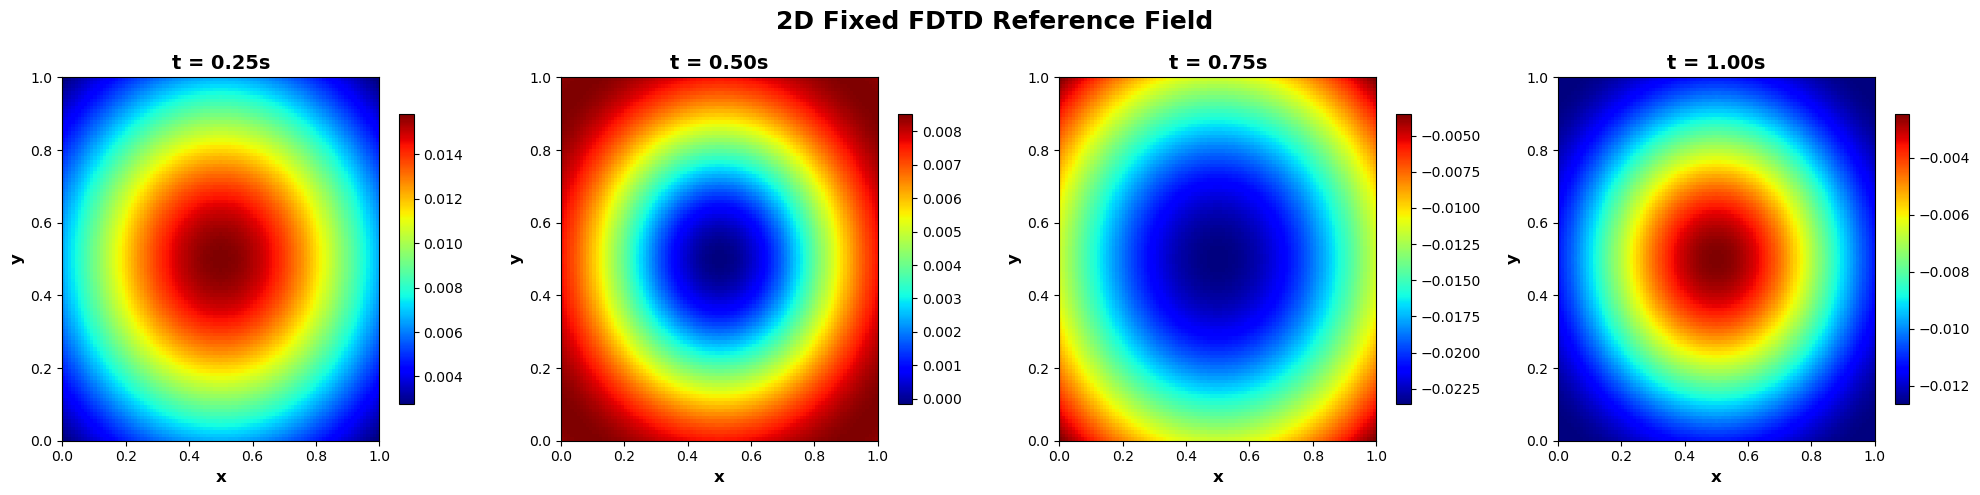

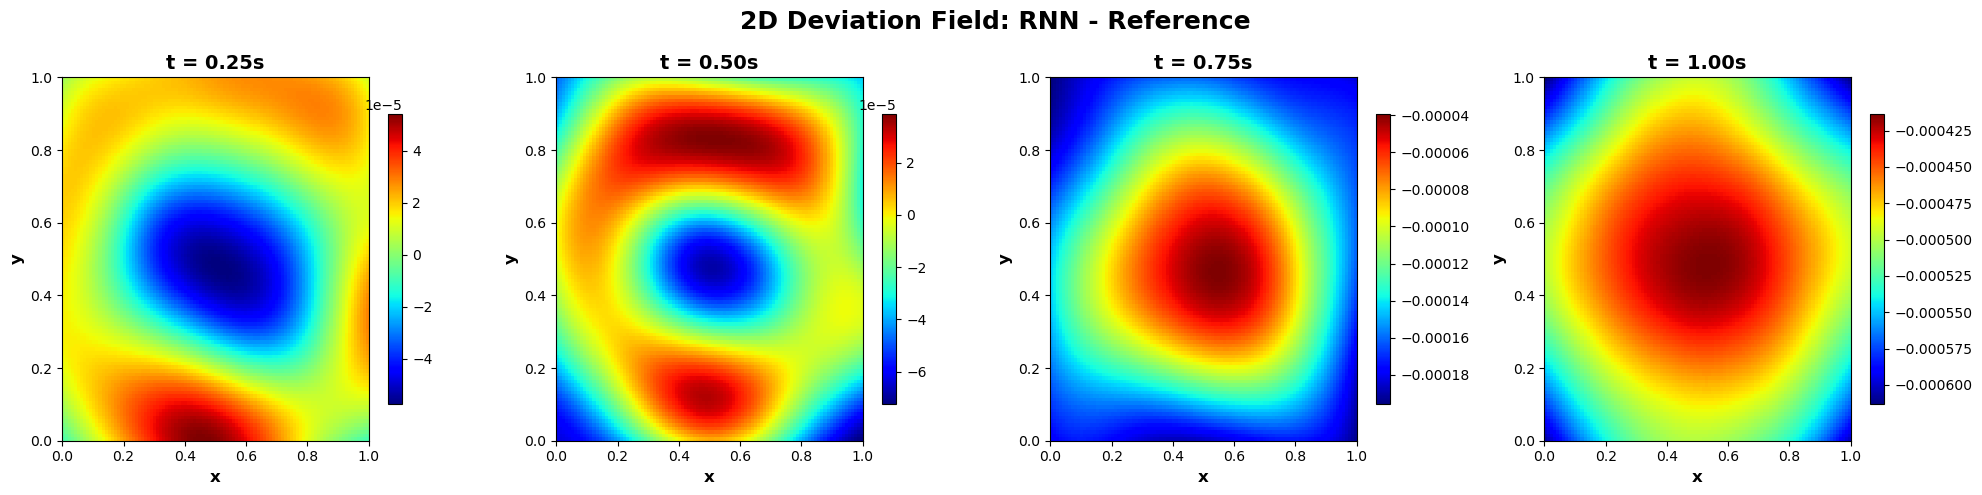

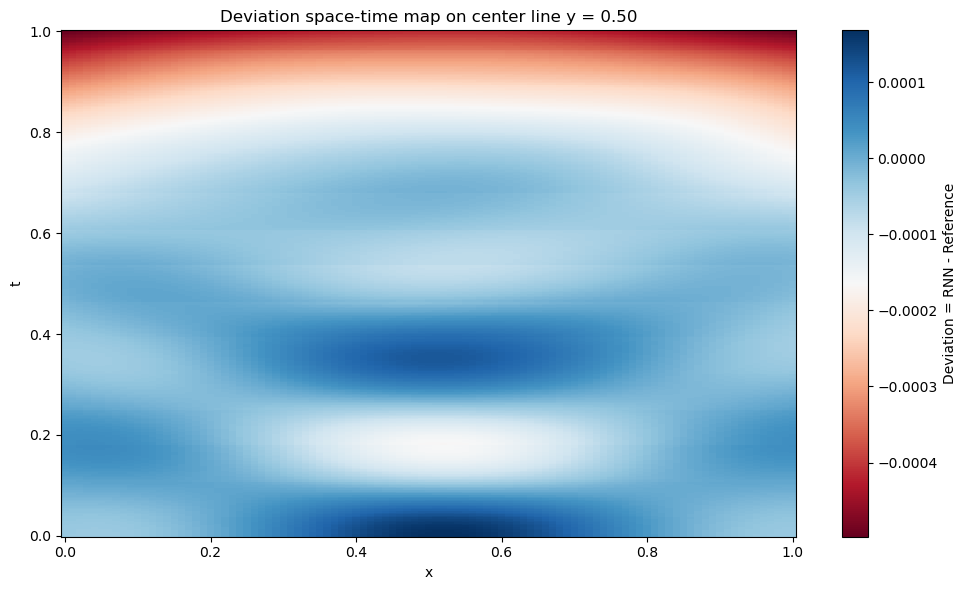

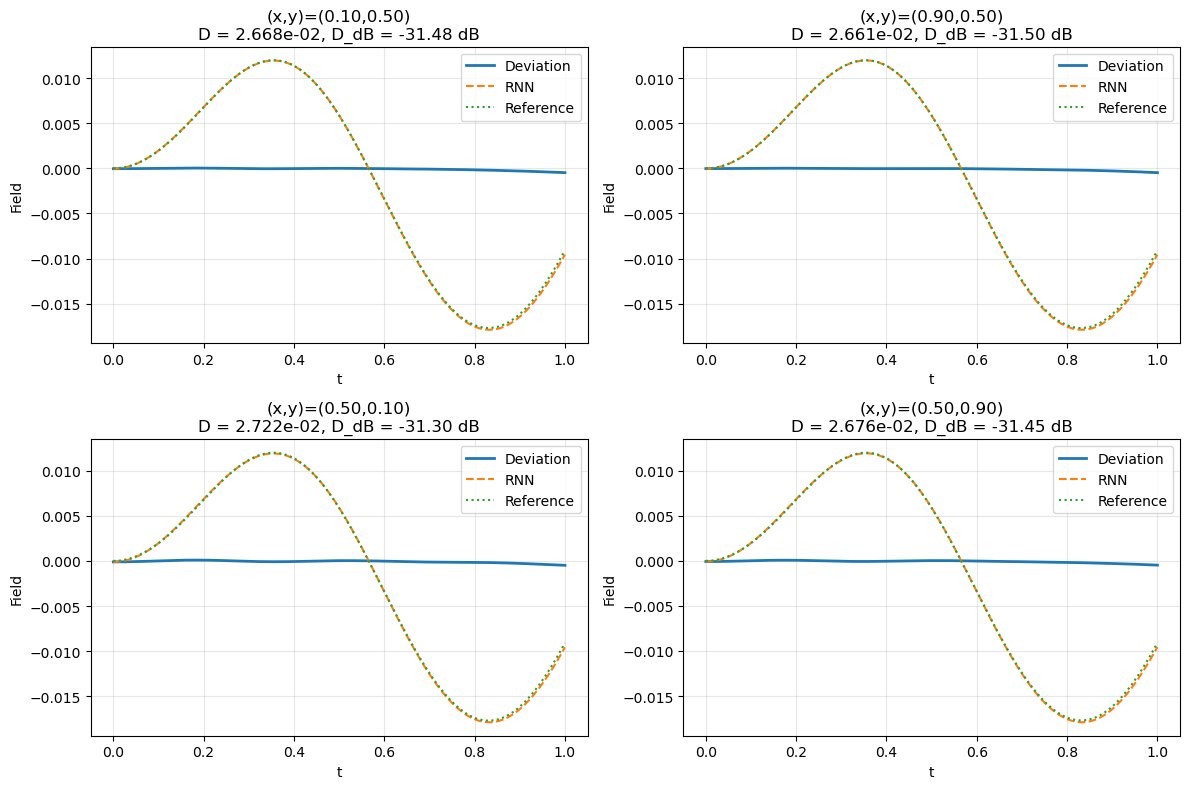

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

# ========== Parameter Configuration ==========
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# =========================
# Parameters consistent with FDTD-PML absorbing boundary
# =========================
c = 2.0
L = 1.0
T = 1.0

# ---------- External PML absorbing layer ----------
pml_width = 1.5
sigma_max = 10.0
sigma_order = 3.0

# Extended computational domain
x_left = -pml_width
x_right = L + pml_width
y_bottom = -pml_width
y_top = L + pml_width

# ---------- Random feature parameters ----------
num_neuron = 10000
r_neuron = [5, 5, 5]   # t, x, y
d = 3

# ---------- Source parameters (consistent with FDTD) ----------
x_src, y_src = L / 2.0, L / 2.0
sigma_src = 0.3
omega = 2.0 * np.pi

# ---------- Collocation weights ----------
p_pde = 1.0
p_bnd = 10.0
p_ini_u = 10.0
p_ini_v = 10.0

# ---------- Training point counts ----------
N_pde = 20000
N_bnd = 20000
N_ini = 10000

# ---------- Fixed reference solution file ----------
reference_file = "2d_fdtd_ref_2e-4.npy"

# ---------- Probe points (consistent with previous FDTD detection aperture) ----------
probe_points = [
    (0.1, 0.5),
    (0.9, 0.5),
    (0.5, 0.1),
    (0.5, 0.9),
]

# ---------- Boundary band width ----------
boundary_band = 0.3

# ========== Activation function and derivatives ==========
def atv(x):
    return torch.tanh(x)

def diff1_atv(x):
    return 1.0 - torch.tanh(x) ** 2

def diff2_atv(x):
    th = torch.tanh(x)
    return 2.0 * th * (th**2 - 1.0)

# ========== Damping function sigma(x, y) ==========
def sigma_xy(X, Y):
    """
    In the main domain [0,L]x[0,L], sigma = 0
    In the outer absorbing layer, sigma increases polynomially
    """
    sig = torch.zeros_like(X, dtype=dtype, device=X.device)

    left_mask = X < 0.0
    if left_mask.any():
        sig[left_mask] += sigma_max * ((0.0 - X[left_mask]) / pml_width) ** sigma_order

    right_mask = X > L
    if right_mask.any():
        sig[right_mask] += sigma_max * ((X[right_mask] - L) / pml_width) ** sigma_order

    bottom_mask = Y < 0.0
    if bottom_mask.any():
        sig[bottom_mask] += sigma_max * ((0.0 - Y[bottom_mask]) / pml_width) ** sigma_order

    top_mask = Y > L
    if top_mask.any():
        sig[top_mask] += sigma_max * ((Y[top_mask] - L) / pml_width) ** sigma_order

    return sig

# ========== Training Data Generation ==========
def generate_points():
    # PDE internal points: uniform sampling over the extended domain
    ti = torch.rand(N_pde, 1, device=device, dtype=dtype) * T
    xi = x_left + (x_right - x_left) * torch.rand(N_pde, 1, device=device, dtype=dtype)
    yi = y_bottom + (y_top - y_bottom) * torch.rand(N_pde, 1, device=device, dtype=dtype)

    # Enhanced sampling near the source
    n_focus = N_pde // 100
    xi_focus = torch.normal(
        mean=x_src,
        std=0.3,
        size=(n_focus, 1),
        device=device,
        dtype=dtype
    ).clamp(x_left, x_right)

    yi_focus = torch.normal(
        mean=y_src,
        std=0.3,
        size=(n_focus, 1),
        device=device,
        dtype=dtype
    ).clamp(y_bottom, y_top)

    ti_focus = torch.rand(n_focus, 1, device=device, dtype=dtype) * T

    pti_uniform = torch.cat((ti, xi, yi), dim=1)
    pti_focus = torch.cat((ti_focus, xi_focus, yi_focus), dim=1)
    pti = torch.cat((pti_uniform, pti_focus), dim=0)

    # Outer boundary points: the four outermost edges of the extended domain
    tb = torch.rand(N_bnd, 1, device=device, dtype=dtype) * T
    xb = x_left + (x_right - x_left) * torch.rand(N_bnd, 1, device=device, dtype=dtype)
    yb = y_bottom + (y_top - y_bottom) * torch.rand(N_bnd, 1, device=device, dtype=dtype)

    ptb_x0 = torch.cat((tb, torch.full_like(tb, x_left), yb), dim=1)
    ptb_x1 = torch.cat((tb, torch.full_like(tb, x_right), yb), dim=1)
    ptb_y0 = torch.cat((tb, xb, torch.full_like(tb, y_bottom)), dim=1)
    ptb_y1 = torch.cat((tb, xb, torch.full_like(tb, y_top)), dim=1)

    ptb = torch.cat((ptb_x0, ptb_x1, ptb_y0, ptb_y1), dim=0)

    # Initial conditions: t=0 over the extended domain
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=dtype)
    xi_ini = x_left + (x_right - x_left) * torch.rand(N_ini, 1, device=device, dtype=dtype)
    yi_ini = y_bottom + (y_top - y_bottom) * torch.rand(N_ini, 1, device=device, dtype=dtype)
    pt_ini = torch.cat((ti_ini, xi_ini, yi_ini), dim=1)

    return pti, ptb, pt_ini

# ========== PDE Residual ==========
def wave_equation_residual(W, b, points, c):
    Tt = points[:, 0:1]
    X = points[:, 1:2]
    Y = points[:, 2:3]

    W_t = W[0:1, :]
    W_x = W[1:2, :]
    W_y = W[2:3, :]

    Z = Tt @ W_t + X @ W_x + Y @ W_y + b

    phi_t = W_t * diff1_atv(Z)
    phi_tt = (W_t ** 2) * diff2_atv(Z)
    phi_xx = (W_x ** 2) * diff2_atv(Z)
    phi_yy = (W_y ** 2) * diff2_atv(Z)

    sig = sigma_xy(X, Y)

    # u_tt + sigma*u_t - c^2(u_xx + u_yy)
    return phi_tt + sig * phi_t - (c ** 2) * (phi_xx + phi_yy)

# ========== Initial Velocity Residual ==========
def ini_t_residual(W, b, points):
    Tt = points[:, 0:1]
    X = points[:, 1:2]
    Y = points[:, 2:3]

    W_t = W[0:1, :]
    W_x = W[1:2, :]
    W_y = W[2:3, :]

    Z = Tt @ W_t + X @ W_x + Y @ W_y + b
    return W_t * diff1_atv(Z)

# ========== Source Term ==========
def source_term(points):
    Tt = points[:, 0:1]
    X = points[:, 1:2]
    Y = points[:, 2:3]

    return (
        torch.cos(omega * Tt) *
        torch.exp(-((X - x_src) ** 2 + (Y - y_src) ** 2) / (2.0 * sigma_src ** 2))
    )

# ========== Utility Function ==========
def get_nearest_idx_2d(xq, yq, x_grid, y_grid):
    ix = np.argmin(np.abs(x_grid - xq))
    iy = np.argmin(np.abs(y_grid - yq))
    return ix, iy

# ========== Main Program ==========
start_time = time.time()

# Initialize random feature parameters
W1 = torch.tensor(
    np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)),
    dtype=dtype, device=device
)
W2 = torch.tensor(
    np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)),
    dtype=dtype, device=device
)
W3 = torch.tensor(
    np.random.uniform(-r_neuron[2], r_neuron[2], (1, num_neuron)),
    dtype=dtype, device=device
)
W = torch.cat((W1, W2, W3), dim=0)

# Bias initialization: covers the extended domain
b1 = torch.tensor(
    np.random.uniform(0.0, T, (1, num_neuron)),
    dtype=dtype, device=device
)
b2 = torch.tensor(
    np.random.uniform(x_left, x_right, (1, num_neuron)),
    dtype=dtype, device=device
)
b3 = torch.tensor(
    np.random.uniform(y_bottom, y_top, (1, num_neuron)),
    dtype=dtype, device=device
)
b_shift = torch.cat((b1, b2, b3), dim=0)
b = -torch.sum(b_shift * W, dim=0, keepdim=True)

# Training points
pti, ptb, pt_ini = generate_points()

# Construct matrix blocks
A_pde = wave_equation_residual(W, b, pti, c)
A_bnd = atv(ptb @ W + b)                # u=0 on the outermost boundary of the extended domain
A_ini_u = atv(pt_ini @ W + b)           # u(x,y,0)=0
A_ini_v = ini_t_residual(W, b, pt_ini)  # u_t(x,y,0)=0

A = torch.cat([
    p_pde * A_pde,
    p_bnd * A_bnd,
    p_ini_u * A_ini_u,
    p_ini_v * A_ini_v
], dim=0)

F_pde = source_term(pti)
F_bnd = torch.zeros((ptb.shape[0], 1), dtype=dtype, device=device)
F_ini_u = torch.zeros((pt_ini.shape[0], 1), dtype=dtype, device=device)
F_ini_v = torch.zeros((pt_ini.shape[0], 1), dtype=dtype, device=device)

F = torch.cat([
    p_pde * F_pde,
    p_bnd * F_bnd,
    p_ini_u * F_ini_u,
    p_ini_v * F_ini_v
], dim=0)

# Least squares solution
Ur = torch.linalg.lstsq(A, F).solution

end_time = time.time()
print("Total_time:", end_time - start_time)

# ========== Load Fixed Reference Solution ==========
fdtd = np.load(reference_file).astype(np.float64)
print("Loaded fixed FDTD reference shape:", fdtd.shape)

nt_ref, nx_ref, ny_ref = fdtd.shape

# Predict only in the main domain for direct comparison with the fixed reference solution
t_test = torch.linspace(0.0, T, nt_ref, device=device, dtype=dtype)
x_test = torch.linspace(0.0, L, nx_ref, device=device, dtype=dtype)
y_test = torch.linspace(0.0, L, ny_ref, device=device, dtype=dtype)

T_mesh, X_mesh, Y_mesh = torch.meshgrid(t_test, x_test, y_test, indexing='ij')
test_points = torch.cat(
    (
        T_mesh.reshape(-1, 1),
        X_mesh.reshape(-1, 1),
        Y_mesh.reshape(-1, 1)
    ),
    dim=1
)

# ========== Batch Prediction ==========
batch_size = 40000
u_pred = []

with torch.no_grad():
    for i in range(0, test_points.shape[0], batch_size):
        batch = test_points[i:i + batch_size]
        hidden = torch.tanh(batch @ W + b)
        output = hidden @ Ur
        u_pred.append(output.cpu())

u_pred = torch.cat(u_pred, dim=0).numpy().reshape(nt_ref, nx_ref, ny_ref)

# ========== Error ==========
error = u_pred - fdtd
rel_err = np.linalg.norm(error.ravel()) / np.linalg.norm(fdtd.ravel())
print(f"Relative L2 Error: {rel_err:.2%}")

# ============================================================
# Deviation curves at four probe points + Normalized deviation metric
# ============================================================
probe_results = []

print("\n===== Probe-point normalized deviation indicators =====")
x_grid = np.linspace(0.0, L, nx_ref)
y_grid = np.linspace(0.0, L, ny_ref)
t_grid = np.linspace(0.0, T, nt_ref)

for (xp, yp) in probe_points:
    ix, iy = get_nearest_idx_2d(xp, yp, x_grid, y_grid)

    trace_num = u_pred[:, ix, iy]
    trace_ref = fdtd[:, ix, iy]
    trace_err = trace_num - trace_ref

    numerator = np.max(np.abs(trace_err))
    denominator = np.max(np.abs(trace_ref))
    D = numerator / max(denominator, 1e-15)
    D_dB = 20.0 * np.log10(max(D, 1e-15))

    probe_results.append({
        "x": x_grid[ix],
        "y": y_grid[iy],
        "ix": ix,
        "iy": iy,
        "trace_num": trace_num,
        "trace_ref": trace_ref,
        "trace_err": trace_err,
        "D": D,
        "D_dB": D_dB
    })

    print(f"(x, y)=({x_grid[ix]:.2f}, {y_grid[iy]:.2f}) : D = {D:.6e}, D_dB = {D_dB:.2f} dB")

# ============================================================
# Normalized deviation metric near boundaries
# ============================================================
xv, yv = np.meshgrid(x_grid, y_grid, indexing='ij')
boundary_mask = (
    (xv <= boundary_band) |
    (xv >= L - boundary_band) |
    (yv <= boundary_band) |
    (yv >= L - boundary_band)
)

D_map = np.zeros((nx_ref, ny_ref), dtype=np.float64)
D_map_dB = np.zeros((nx_ref, ny_ref), dtype=np.float64)

for i in range(nx_ref):
    for j in range(ny_ref):
        ref_trace = fdtd[:, i, j]
        err_trace = error[:, i, j]

        numerator = np.max(np.abs(err_trace))
        denominator = np.max(np.abs(ref_trace))
        D_local = numerator / max(denominator, 1e-15)

        D_map[i, j] = D_local
        D_map_dB[i, j] = 20.0 * np.log10(max(D_local, 1e-15))

boundary_D_values = D_map[boundary_mask]
boundary_D_dB_values = D_map_dB[boundary_mask]

print("\n===== Boundary-band normalized deviation metrics =====")
print(f"Boundary band width = {boundary_band}")
print(f"Max   D in boundary band    = {np.max(boundary_D_values):.6e}")
print(f"Mean  D in boundary band    = {np.mean(boundary_D_values):.6e}")
print(f"Max   D_dB in boundary band = {np.max(boundary_D_dB_values):.2f} dB")
print(f"Mean  D_dB in boundary band = {np.mean(boundary_D_dB_values):.2f} dB")

# ============================================================
# Dynamic time slices
# ============================================================
target_times_ratio = [0.25, 0.5, 0.75, 1.0]
target_times = np.array(target_times_ratio) * T
time_indices = np.floor(np.array(target_times_ratio) * (nt_ref - 1)).astype(int)

# ============================================================
# Visualization 1: Main domain snapshots
# ============================================================
def plot_snapshots(field_data, title):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    vmax = np.max(np.abs(field_data))
    vmin = -vmax

    for idx, (ax, t_idx) in enumerate(zip(axs.flat, time_indices)):
        im = ax.imshow(
            field_data[t_idx].T,
            extent=[0, L, 0, L],
            origin='lower',
            cmap='jet',
            aspect='auto'
        )
        ax.set_title(f"t = {target_times[idx]:.2f}s", fontweight='bold', fontsize=14)
        ax.set_xlabel("x", fontsize=12, fontweight='bold')
        ax.set_ylabel("y", fontsize=12, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle(title, fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_snapshots(u_pred, "2D RNN Wave Field with Damping Absorbing Layers")
plot_snapshots(fdtd, "2D Fixed FDTD Reference Field")
plot_snapshots(error, "2D Deviation Field: RNN - Reference")

# ============================================================
# Visualization 2: Main domain deviation space-time plot
# Taking the y = L/2 midline
# ============================================================
iy_mid = np.argmin(np.abs(y_grid - L / 2.0))
error_xt = error[:, :, iy_mid]

X_plot, T_plot = np.meshgrid(x_grid, t_grid)

plt.figure(figsize=(10, 6))
plt.pcolormesh(X_plot, T_plot, error_xt, shading='auto', cmap='RdBu')
plt.colorbar(label='Deviation = RNN - Reference')
plt.xlabel('x')
plt.ylabel('t')
plt.title(f'Deviation space-time map on center line y = {y_grid[iy_mid]:.2f}')
plt.tight_layout()
plt.show()

# ============================================================
# Visualization 3: Deviation curves at four probe points
# ============================================================
plt.figure(figsize=(12, 8))
for k, item in enumerate(probe_results):
    plt.subplot(2, 2, k + 1)
    plt.plot(t_grid, item["trace_err"], linewidth=2, label='Deviation')
    plt.plot(t_grid, item["trace_num"], '--', linewidth=1.5, label='RNN')
    plt.plot(t_grid, item["trace_ref"], ':', linewidth=1.5, label='Reference')
    plt.xlabel('t')
    plt.ylabel('Field')
    plt.title(
        f"(x,y)=({item['x']:.2f},{item['y']:.2f})\n"
        f"D = {item['D']:.3e}, D_dB = {item['D_dB']:.2f} dB"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()